In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

pd.set_option("display.max_columns", None)
plt.rcParams["figure.figsize"] = (9,5)

print("✅ Imports OK")


✅ Imports OK


In [12]:
# adjust the filename if yours is different
csv_path = "../data/Superstore.csv"

# some Superstore files need latin-1 due to special chars
df = pd.read_csv(csv_path, encoding="latin-1")
print(df.shape)
df.head()


(9994, 21)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [13]:
# tidy column names
df.columns = df.columns.str.strip().str.replace(" ", "_")

# keep the columns we need
keep_cols = ["Order_Date","Product_Name","Category","Sales","Quantity","Profit","Region"]
df = df[keep_cols].copy()

# rename to standard names
df.rename(columns={"Sales":"Revenue", "Quantity":"Units_Sold"}, inplace=True)

# create unit Price (Revenue is line total in Superstore)
df["Price"] = df["Revenue"] / df["Units_Sold"]

# dates to datetime
df["Order_Date"] = pd.to_datetime(df["Order_Date"], errors="coerce")

# drop rows with any critical missing or invalid numbers
df = df.dropna(subset=["Order_Date","Revenue","Units_Sold","Price"])

# remove non-sensical rows
df = df[(df["Units_Sold"] > 0) & (df["Price"] > 0) & (df["Revenue"] > 0)]

print(df.shape)
df.head()


(9994, 8)


,Order_Date,Product_Name,Category,Revenue,Units_Sold,Profit,Region,Price
0,2016-11-08,Bush Somerset Collection Bookcase,Furniture,261.9600,2,41.9136,South,130.9800
1,2016-11-08,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",Furniture,731.9400,3,219.5820,South,243.9800
2,2016-06-12,Self-Adhesive Address Labels for Typewriters b...,Office Supplies,14.6200,2,6.8714,West,7.3100
3,2015-10-11,Bretford CR4500 Series Slim Rectangular Table,Furniture,957.5775,5,-383.0310,South,191.5155
4,2015-10-11,Eldon Fold 'N Roll Cart System,Office Supplies,22.3680,2,2.5164,South,11.1840


In [16]:
# Summary only for numeric columns
display(df.select_dtypes(include="number").describe())

print("\nNulls per column:\n", df.isna().sum())
print("\nCategories:", sorted(df["Category"].unique()))


,Revenue,Units_Sold,Profit,Price
count,9994.000000,9994.000000,9994.000000,9994.000000
mean,229.858001,3.789574,28.656896,60.919569
std,623.245101,2.225110,234.260108,142.927440
min,0.444000,1.000000,-6599.978000,0.336000
25%,17.280000,2.000000,1.728750,5.470000
50%,54.490000,3.000000,8.666500,16.270000
75%,209.940000,5.000000,29.364000,63.940000
max,22638.480000,14.000000,8399.976000,3773.080000



Nulls per column:
 Order_Date      0
Product_Name    0
Category        0
Revenue         0
Units_Sold      0
Profit          0
Region          0
Price           0
dtype: int64

Categories: ['Furniture', 'Office Supplies', 'Technology']


In [17]:
# cap extreme outliers that can distort the fit
p99_price = df["Price"].quantile(0.99)
p99_units = df["Units_Sold"].quantile(0.99)

df_filt = df[(df["Price"] <= p99_price) & (df["Units_Sold"] <= p99_units)].copy()
print("Before:", df.shape, "After:", df_filt.shape)


Before: (9994, 8) After: (9816, 8)


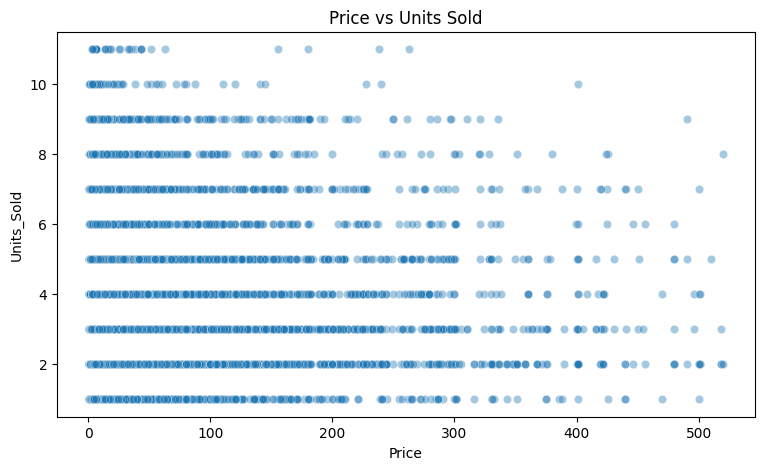

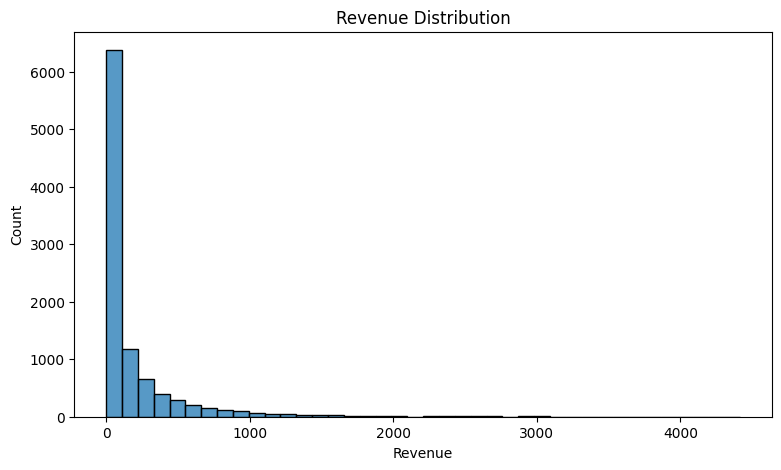

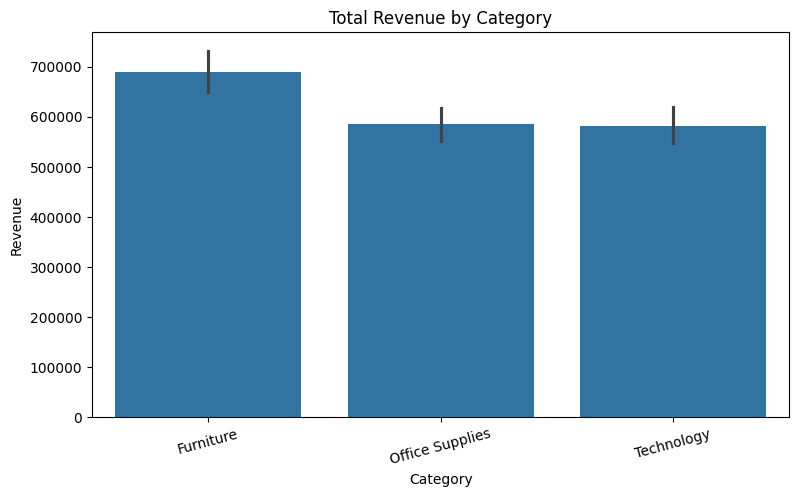

In [ ]:
#EDA, a few core plots
sns.scatterplot(data=df_filt, x="Price", y="Units_Sold", alpha=0.4)
plt.title("Price vs Units Sold")
plt.show()

sns.histplot(df_filt["Revenue"], bins=40)
plt.title("Revenue Distribution")
plt.show()

sns.barplot(data=df_filt, x="Category", y="Revenue", estimator=sum, order=sorted(df_filt["Category"].unique()))
plt.title("Total Revenue by Category")
plt.xticks(rotation=15)
plt.show()


In [19]:
#fit demand model-overall
X = df_filt[["Price"]]
y = df_filt["Units_Sold"]

model = LinearRegression()
model.fit(X, y)

coef = float(model.coef_[0])
intercept = float(model.intercept_)
print(f"Coefficient (should be negative): {coef:.4f}")
print(f"Intercept: {intercept:.2f}")


Coefficient (should be negative): -0.0001
Intercept: 3.72


💰 Optimal Price: 519.86
📈 Revenue at Optimal Price: 1916.37


/Users/antara/Documents/price-optimization-project/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


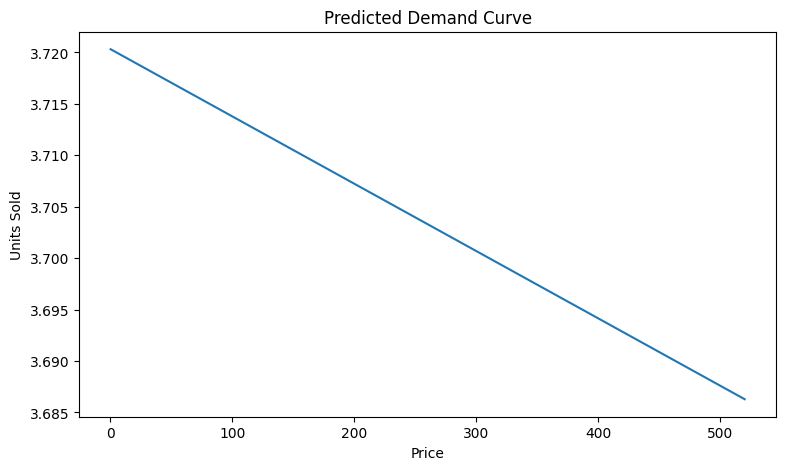

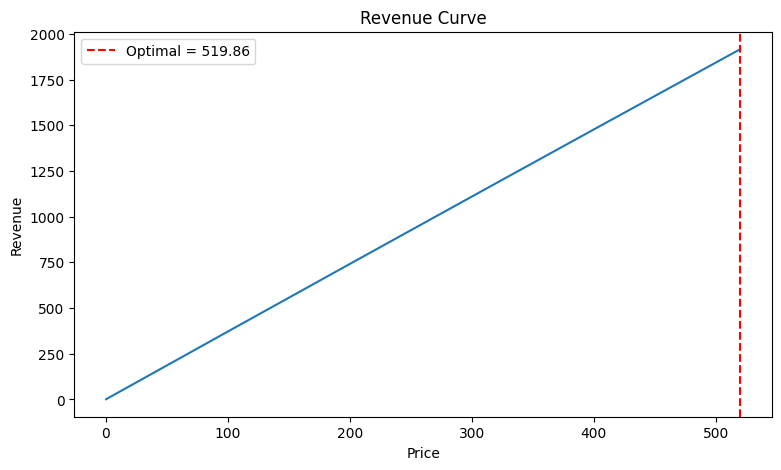

In [20]:
#find optimal price overall
prices = np.linspace(df_filt["Price"].min(), df_filt["Price"].max(), 200)
pred_demand = model.predict(prices.reshape(-1,1))
revenue_curve = prices * pred_demand

optimal_price = float(prices[np.argmax(revenue_curve)])
optimal_rev   = float(revenue_curve.max())

print(f"💰 Optimal Price: {optimal_price:.2f}")
print(f"📈 Revenue at Optimal Price: {optimal_rev:.2f}")

# demand curve
plt.plot(prices, pred_demand)
plt.xlabel("Price"); plt.ylabel("Units Sold"); plt.title("Predicted Demand Curve")
plt.show()

# revenue curve
plt.plot(prices, revenue_curve)
plt.axvline(optimal_price, color="red", linestyle="--", label=f"Optimal = {optimal_price:.2f}")
plt.xlabel("Price"); plt.ylabel("Revenue"); plt.title("Revenue Curve")
plt.legend(); plt.show()


/Users/antara/Documents/price-optimization-project/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/Users/antara/Documents/price-optimization-project/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/Users/antara/Documents/price-optimization-project/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


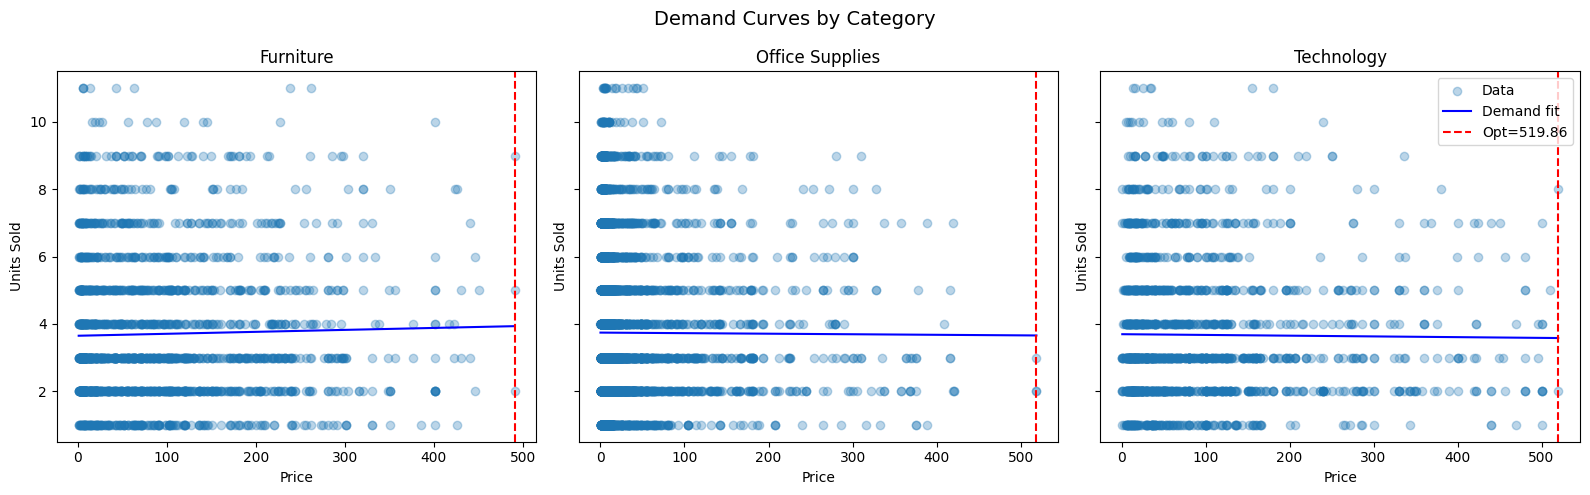

In [24]:
# Demand curves by category
categories = df_filt["Category"].unique()

fig, axes = plt.subplots(1, len(categories), figsize=(16,5), sharey=True)

for ax, cat in zip(axes, categories):
    g = df_filt[df_filt["Category"] == cat]
    if g["Price"].nunique() < 3:
        continue
    
    m = LinearRegression().fit(g[["Price"]], g["Units_Sold"])
    pgrid = np.linspace(g["Price"].min(), g["Price"].max(), 100)
    demand = m.predict(pgrid.reshape(-1,1))
    rev = pgrid * demand
    opt_price = pgrid[np.argmax(rev)]
    
    # scatter
    ax.scatter(g["Price"], g["Units_Sold"], alpha=0.3, label="Data")
    # fitted line
    ax.plot(pgrid, demand, color="blue", label="Demand fit")
    # optimal price marker
    ax.axvline(opt_price, color="red", linestyle="--", label=f"Opt={opt_price:.2f}")
    
    ax.set_title(cat)
    ax.set_xlabel("Price")
    ax.set_ylabel("Units Sold")

plt.suptitle("Demand Curves by Category", fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()


/Users/antara/Documents/price-optimization-project/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/Users/antara/Documents/price-optimization-project/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/Users/antara/Documents/price-optimization-project/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


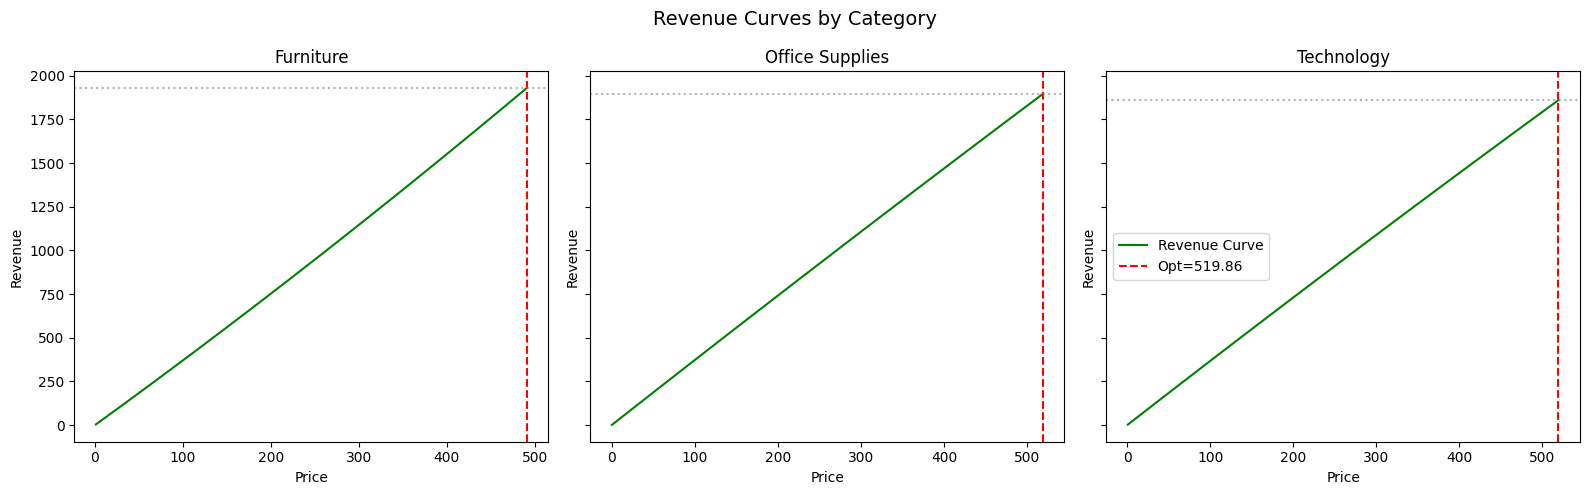

In [25]:
# Revenue curves by category
fig, axes = plt.subplots(1, len(categories), figsize=(16,5), sharey=True)

for ax, cat in zip(axes, categories):
    g = df_filt[df_filt["Category"] == cat]
    if g["Price"].nunique() < 3:
        continue
    
    m = LinearRegression().fit(g[["Price"]], g["Units_Sold"])
    pgrid = np.linspace(g["Price"].min(), g["Price"].max(), 100)
    demand = m.predict(pgrid.reshape(-1,1))
    rev = pgrid * demand
    opt_price = pgrid[np.argmax(rev)]
    max_rev = rev.max()
    
    # revenue curve
    ax.plot(pgrid, rev, color="green", label="Revenue Curve")
    ax.axvline(opt_price, color="red", linestyle="--", label=f"Opt={opt_price:.2f}")
    ax.axhline(max_rev, color="gray", linestyle=":", alpha=0.6)
    
    ax.set_title(cat)
    ax.set_xlabel("Price")
    ax.set_ylabel("Revenue")

plt.suptitle("Revenue Curves by Category", fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()


In [22]:
#Per-category optimization - imp
opt_rows = []
for cat, g in df_filt.groupby("Category"):
    if g["Price"].nunique() < 3:  # need some variation to fit
        continue
    m = LinearRegression().fit(g[["Price"]], g["Units_Sold"])
    pgrid = np.linspace(g["Price"].min(), g["Price"].max(), 200)
    demand = m.predict(pgrid.reshape(-1,1))
    rev = pgrid * demand
    opt_rows.append({
        "Category": cat,
        "Coef": float(m.coef_[0]),
        "Intercept": float(m.intercept_),
        "Optimal_Price": float(pgrid[np.argmax(rev)]),
        "Max_Revenue": float(rev.max())
    })

opt_df = pd.DataFrame(opt_rows).sort_values("Max_Revenue", ascending=False)
opt_df


/Users/antara/Documents/price-optimization-project/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/Users/antara/Documents/price-optimization-project/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/Users/antara/Documents/price-optimization-project/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


,Category,Coef,Intercept,Optimal_Price,Max_Revenue
0,Furniture,0.000581,3.647162,490.686,1929.396560
1,Office Supplies,-0.000164,3.740836,518.312,1894.953846
2,Technology,-0.000219,3.693487,519.864,1860.846618


In [23]:
# overall
overall = pd.DataFrame({
    "Optimal Price":[optimal_price],
    "Revenue at Optimal Price":[optimal_rev]
})

overall.to_excel("../data/superstore_price_optimization_overall.xlsx", index=False)

# per category (if computed)
if "opt_df" in globals() and not opt_df.empty:
    opt_df.to_excel("../data/superstore_price_optimization_by_category.xlsx", index=False)

print("✅ Exported to data/ folder")


✅ Exported to data/ folder
